## 1. Data Preprocessing

In [ ]:
# Import the required libralies
import pandas as pd
import numpy as np

In [ ]:
# Load the dataset
from google.colab import files
from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/Colab Notebooks/Ali New Spreadsheet.xlsx'
files.download(file_path)

Mounted at /content/drive


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Define the data
df = pd.read_excel(file_path)

# Show first rows to confirm successful loading
df.head()

,SAMPLE,Lab,CaO,SiO2,Cr2O3,Na2O,TiO2,MnO,MgO,FeO,...,Lu,Hf,Ta,Pb,Th,U,C,M,R,T
0,KL2023-07-19-4_1,Lisbon,22.625,44.409,0.231,0.758,3.365,0.081,11.749,5.069,...,0.188,3.74,0.208,0.038,0.096,0.0176,1,0,0,3
1,KL2023-07-19-4_2,Lisbon,22.752,47.643,0.302,0.764,2.058,0.017,13.116,4.967,...,0.184,3.03,0.238,0.054,0.103,0.0157,0,1,0,3
2,KL2023-07-19-4_3,Lisbon,22.711,49.580,0.189,0.539,1.448,0.141,14.243,4.977,...,0.225,4.09,0.188,0.06,0.113,0.0135,0,0,1,3
3,KL2023-07-19-4_4,Lisbon,23.481,51.316,0.1,0.534,0.057,0.421,7.376,16.404,...,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,3
4,KL2023-07-19-4_5,Lisbon,23.601,51.941,0.118,0.423,0.139,0.388,7.826,15.199,...,NaN,NaN,NaN,NaN,NaN,NaN,0,1,0,3


In [ ]:
# Show column names
df.columns

# Check data types
df.dtypes

,0
SAMPLE,object
Lab,object
CaO,float64
SiO2,float64
Cr2O3,object
Na2O,float64
TiO2,float64
MnO,float64
MgO,float64
FeO,float64


## 2. Data Handling

In [ ]:
# Define which columns belong to EMPA and Laser

# EMPA columns (major oxides, complete)
empa_cols = [
    "CaO", "SiO2", "Cr2O3", "Na2O", "TiO2",
    "MnO", "MgO", "FeO", "Al2O3", "K2O", "Mg#"
]

# Laser Ablation columns (trace elements, 71% missing)
laser_cols = [
    "Li", "Be", "B", "Mg", "Si", "Ca","Ca.1", "Sc", "Ti", "V", "Cr", "Mn",
    "Co", "Ni", "Cu", "Rb", "Sr", "Y", "Zr", "Nb", "Cs", "Ba", "La", "Ce",
    "Pr", "Nd", "Sm", "Eu", "Gd", "Tb", "Dy", "Ho", "Er", "Tm", "Yb", "Lu",
    "Hf", "Ta", "Pb", "Th", "U"
]

# Metadata columns (keep but don’t use as features)
meta_cols = ["SAMPLE", "Lab", "C", "M", "R", "T"]

In [ ]:
# Create the two datasets
# Using copy function to:
# ---Protect the original data
# ---Avoid accidental changes

# EMPA dataset (complete, no missing values)
df_empa = df[meta_cols + empa_cols].copy()

# Laser Ablation dataset (many missing values)
df_laser = df[meta_cols + laser_cols].copy()

In [ ]:
# Convert the column to string so that "CPX" can be detected safely
df_empa['Cr2O3'] = df_empa['Cr2O3'].astype(str)

# Replace the string "CPX" with NaN (missing value)
df_empa['Cr2O3'] = df_empa['Cr2O3'].replace("CPX", np.nan) #put numpy so that pandas can detect

# Convert the column to numeric values.
# errors='coerce': Any value that cannot be converted, "CPX" is forced to NaN.
df_empa['Cr2O3'] = pd.to_numeric(df_empa['Cr2O3'], errors='coerce')

# Fill the NaN (originally "CPX") with the mean value of the numeric Cr2O3 data
df_empa['Cr2O3'] = df_empa['Cr2O3'].fillna(df_empa['Cr2O3'].mean())

In [ ]:
print("Unique values:", df_empa['Cr2O3'].unique())
print("Dtype:", df_empa['Cr2O3'].dtype)
print("Mean:", df_empa['Cr2O3'].mean())
print("NaN count:", df_empa['Cr2O3'].isna().sum())

Unique values: [ 2.31000000e-01  3.02000000e-01  1.89000000e-01  1.00000000e-01
  1.18000000e-01  1.46000000e-01  8.90000000e-02  8.70000000e-02
  2.00000000e-01  2.98000000e-01  8.80000000e-02  2.50000000e-01
  2.68000000e-01  6.60000000e-02  9.70000000e-02  6.56000000e-01
  8.00000000e-03  2.07000000e-01  6.87000000e-01  2.10000000e-02
  1.18138000e-01  3.27582000e-01  3.33850000e-02  5.26670000e-02
  6.51880000e-02  2.61043000e-01  1.24173000e-01  8.53900000e-03
  9.20000000e-02  7.20000000e-02  1.81000000e-01  1.29000000e-01
  8.40000000e-02  1.13000000e-01  1.17000000e-01  3.83000000e-01
  7.80000000e-02  1.31000000e-01  2.26000000e-01  5.30000000e-02
  1.60000000e-01  1.10000000e-02  1.00000000e-03  0.00000000e+00
  4.00000000e-02  3.61000000e-01  8.10000000e-02  5.00000000e-03
  4.00000000e-03  1.53000000e-01  1.86000000e-01  1.01000000e-01
  7.07000000e-01  7.30000000e-02  5.07000000e-01  2.79000000e-01
  2.00000000e-03  6.00000000e-03  2.13000000e-01  4.90000000e-02
  2.580000

In [ ]:
# After cleaning Cr2O3
X_empa = df_empa[empa_cols].copy()

In [ ]:
df_empa.head() # Check the EMPA dataframe

,SAMPLE,Lab,C,M,R,T,CaO,SiO2,Cr2O3,Na2O,TiO2,MnO,MgO,FeO,Al2O3,K2O,Mg#
0,KL2023-07-19-4_1,Lisbon,1,0,0,3,22.625,44.409,0.231,0.758,3.365,0.081,11.749,5.069,11.660,0.001,0.80247
1,KL2023-07-19-4_2,Lisbon,0,1,0,3,22.752,47.643,0.302,0.764,2.058,0.017,13.116,4.967,7.996,0.007,0.82759
2,KL2023-07-19-4_3,Lisbon,0,0,1,3,22.711,49.580,0.189,0.539,1.448,0.141,14.243,4.977,5.495,0.004,0.83158
3,KL2023-07-19-4_4,Lisbon,1,0,0,3,23.481,51.316,0.100,0.534,0.057,0.421,7.376,16.404,0.564,0.009,0.44330
4,KL2023-07-19-4_5,Lisbon,0,1,0,3,23.601,51.941,0.118,0.423,0.139,0.388,7.826,15.199,0.536,0.003,0.47872


In [ ]:
# Remove "<"
df_laser[laser_cols] = df_laser[laser_cols].replace(r'<', '', regex=True)
# Use regex=True so that "<" is removed even when it appears inside a longer string
# (e.g., "<0.52" becomes "0.52"). Without regex=True, pandas only replaces values
# that exactly match "<", so partial matches would not be cleaned

# Convert to numeric
df_laser[laser_cols] = df_laser[laser_cols].apply(pd.to_numeric, errors='coerce')

# Drop rows where Laser element columns are empty
df_laser_clean = df_laser.dropna(subset=laser_cols)

In [ ]:
df_laser_clean.head(10)

# Check the Laser Ablation dataframe

,SAMPLE,Lab,C,M,R,T,Li,Be,B,Mg,...,Ho,Er,Tm,Yb,Lu,Hf,Ta,Pb,Th,U
0,KL2023-07-19-4_1,Lisbon,1,0,0,3,0.52,0.310,2.87,89280.11,...,0.839,2.26,0.261,1.51,0.188,3.74,0.208,0.038,0.096,0.0176
1,KL2023-07-19-4_2,Lisbon,0,1,0,3,1.59,0.280,2.93,93192.75,...,0.716,1.56,0.201,1.41,0.184,3.03,0.238,0.054,0.103,0.0157
2,KL2023-07-19-4_3,Lisbon,0,0,1,3,1.88,0.155,2.84,97795.37,...,0.882,2.08,0.234,1.64,0.225,4.09,0.188,0.060,0.113,0.0135
14,KL2023-07-19-4_15,Sheffield,1,0,0,3,0.52,0.310,2.87,89280.11,...,0.839,2.26,0.261,1.51,0.188,3.74,0.208,0.038,0.096,0.0176
15,KL2023-07-19-4_16,Sheffield,0,1,0,3,1.59,0.280,2.93,93192.75,...,0.716,1.56,0.201,1.41,0.184,3.03,0.238,0.054,0.103,0.0157
16,KL2023-07-19-4_17,Sheffield,0,0,1,3,1.88,0.155,2.84,97795.37,...,0.882,2.08,0.234,1.64,0.225,4.09,0.188,0.060,0.113,0.0135
17,KL2023-07-19-4_18,Sheffield,1,0,0,3,2.44,0.570,2.96,87143.91,...,0.931,2.40,0.338,1.85,0.277,7.59,0.533,0.253,0.221,0.0462
18,KL2023-07-19-4_19,Sheffield,0,1,0,3,1.73,0.120,2.62,99992.08,...,0.945,2.43,0.307,1.74,0.290,4.70,0.269,0.093,0.172,0.0274
19,KL2023-07-19-4_20,Sheffield,0,0,1,3,5.18,0.410,2.71,94521.02,...,1.222,3.26,0.358,2.69,0.353,6.41,0.552,0.122,0.260,0.0359
23,KL2023-07-19-4_24,Utrecht,1,0,0,3,1.88,0.155,2.84,97795.37,...,0.882,2.08,0.234,1.64,0.225,4.09,0.188,0.060,0.113,0.0135


In [ ]:
# Making the data mathematically suitable for machine learning

Although the raw geochemical values appear usable, the features span very different numerical ranges (e.g., SiO₂ ≈ 50 wt%, MnO ≈ 0.1 wt%).

Machine learning algorithms are sensitive to such scale differences, which can cause large‑magnitude features to dominate the model.

Therefore, normalization (StandardScaler) was applied to ensure all features contribute equally during training.

In [ ]:
# Normalize EMPA dataset
from sklearn.preprocessing import StandardScaler

# Select only EMPA chemical columns (exclude metadata)
X_empa = df_empa[empa_cols]

# Create normalization tool that will later be used to scale data
scaler_empa = StandardScaler()

# Fit and transform
X_empa_scaled = scaler_empa.fit_transform(X_empa)

# X_empa_scaled is NumPy array containing the normalized values

# Convert scaled NumPy array back into a pandas DataFrame
# DataFrames are easier to read, keep the column names, suitable for plotting

df_empa_scaled = pd.DataFrame(X_empa_scaled, columns=empa_cols)

In [ ]:
df_empa_scaled.head()

,CaO,SiO2,Cr2O3,Na2O,TiO2,MnO,MgO,FeO,Al2O3,K2O,Mg#
0,0.071384,-0.961437,1.070884,0.075864,1.533196,-0.684652,-0.232759,-0.858870,1.748814,-0.859442,0.538372
1,0.286364,0.490999,1.666582,0.100577,-0.320164,-1.642151,0.519800,-0.910153,-0.185784,-0.448275,0.843369
2,0.216961,1.360933,0.718499,-0.826169,-1.185159,0.213003,1.140234,-0.905125,-1.506316,-0.653859,0.891814
3,1.520382,2.140596,-0.028220,-0.846763,-3.157633,4.402060,-2.640175,4.840088,-4.109892,-0.311220,-3.822518
4,1.723513,2.421292,0.122802,-1.303958,-3.041355,3.908350,-2.392442,4.234244,-4.124677,-0.722387,-3.392463


In [ ]:
df_empa_scaled.describe()

,CaO,SiO2,Cr2O3,Na2O,TiO2,MnO,MgO,FeO,Al2O3,K2O,Mg#
count,6.530000e+02,6.530000e+02,6.530000e+02,6.530000e+02,6.530000e+02,6.530000e+02,6.530000e+02,6.530000e+02,6.530000e+02,6.530000e+02,6.530000e+02
mean,3.264362e-15,-1.088121e-15,8.704965e-17,1.251339e-16,3.590798e-16,4.080452e-16,2.611489e-16,-2.829113e-16,4.134858e-16,-8.704965e-17,-5.005355e-16
std,1.000767e+00,1.000767e+00,1.000767e+00,1.000767e+00,1.000767e+00,1.000767e+00,1.000767e+00,1.000767e+00,1.000767e+00,1.000767e+00,1.000767e+00
min,-3.931982e+00,-3.315246e+00,-9.955160e-01,-2.115376e+00,-3.157633e+00,-1.642151e+00,-3.446684e+00,-1.468736e+00,-4.124677e+00,-9.279703e-01,-4.068021e+00
25%,-6.480369e-01,-6.124306e-01,-6.742588e-01,-5.502047e-01,-6.775060e-01,-5.799256e-01,-5.074671e-01,-6.431792e-01,-6.958338e-01,-7.223867e-01,-3.104453e-01
50%,-6.482759e-03,5.895056e-02,-2.631434e-01,-2.923304e-01,-1.024966e-01,-2.208635e-01,1.812312e-01,-2.847004e-01,4.072847e-02,-2.426918e-01,2.850991e-01
75%,7.383295e-01,7.036992e-01,1.563620e-01,1.582411e-01,5.774466e-01,2.578859e-01,6.783492e-01,3.030439e-01,6.743304e-01,5.796425e-01,6.432756e-01
max,3.169126e+00,2.435664e+00,6.230801e+00,4.944369e+00,3.796365e+00,6.885573e+00,2.100888e+00,4.840088e+00,3.426275e+00,1.010501e+01,1.434664e+00


In [ ]:
df_empa_scaled.shape

(653, 11)

In [ ]:
# Normalize Laser dataset

# Select only Laser chemical columns (exclude metadata)
X_laser = df_laser_clean[laser_cols]

# Create normalization tool that will later be used to scale data
scaler_laser = StandardScaler()

# Fit and transform
X_laser_scaled = scaler_laser.fit_transform(X_laser)

# Convert back to DataFrame
df_laser_scaled = pd.DataFrame(X_laser_scaled, columns=laser_cols)

In [ ]:
df_laser_scaled.head()

,Li,Be,B,Mg,Si,Ca,Ca.1,Sc,Ti,V,...,Ho,Er,Tm,Yb,Lu,Hf,Ta,Pb,Th,U
0,-1.092096,-0.684891,-0.549753,0.59295,0.426055,-0.485469,0.68163,1.340234,-0.048224,0.586999,...,-0.685710,-0.569194,-0.745987,-0.972304,-1.037863,-0.966442,-0.724019,-0.655553,-0.597473,-0.477491
1,-0.956421,-0.729205,-0.422160,0.82641,0.451111,-0.836646,0.68163,1.313538,-0.659639,-0.239171,...,-1.115204,-1.450791,-1.310292,-1.105774,-1.070673,-1.215964,-0.692419,-0.633660,-0.583015,-0.497377
2,-0.919649,-0.913847,-0.613550,1.10104,0.895314,-1.236320,0.68163,1.307055,-1.374767,-1.151712,...,-0.535561,-0.795890,-0.999924,-0.798793,-0.734364,-0.843438,-0.745086,-0.625450,-0.562360,-0.520404
3,-1.092096,-0.684891,-0.549753,0.59295,0.426055,-0.485469,0.68163,1.340234,-0.048224,0.586999,...,-0.685710,-0.569194,-0.745987,-0.972304,-1.037863,-0.966442,-0.724019,-0.655553,-0.597473,-0.477491
4,-0.956421,-0.729205,-0.422160,0.82641,0.451111,-0.836646,0.68163,1.313538,-0.659639,-0.239171,...,-1.115204,-1.450791,-1.310292,-1.105774,-1.070673,-1.215964,-0.692419,-0.633660,-0.583015,-0.497377


In [ ]:
df_laser_scaled.describe()

,Li,Be,B,Mg,Si,Ca,Ca.1,Sc,Ti,V,...,Ho,Er,Tm,Yb,Lu,Hf,Ta,Pb,Th,U
count,1.890000e+02,1.890000e+02,1.890000e+02,1.890000e+02,1.890000e+02,1.890000e+02,1.890000e+02,1.890000e+02,1.890000e+02,1.890000e+02,...,1.890000e+02,1.890000e+02,1.890000e+02,1.890000e+02,1.890000e+02,1.890000e+02,1.890000e+02,1.890000e+02,1.890000e+02,1.890000e+02
mean,-2.255691e-16,-9.398713e-17,-7.894919e-16,-4.135434e-16,4.887331e-16,-7.251107e-15,8.846691e-10,-5.639228e-17,-1.033858e-15,-6.015177e-16,...,3.477524e-16,-2.255691e-16,2.255691e-16,-7.518971e-17,-3.195563e-16,-2.255691e-16,-9.398713e-17,5.639228e-17,-4.699357e-17,1.785756e-16
std,1.002656e+00,1.002656e+00,1.002656e+00,1.002656e+00,1.002656e+00,1.002656e+00,1.002656e+00,1.002656e+00,1.002656e+00,1.002656e+00,...,1.002656e+00,1.002656e+00,1.002656e+00,1.002656e+00,1.002656e+00,1.002656e+00,1.002656e+00,1.002656e+00,1.002656e+00,1.002656e+00
min,-1.092096e+00,-1.018723e+00,-2.123402e+00,-2.334262e+00,-2.603713e+00,-3.337560e+00,-2.219902e+00,-1.918149e+00,-2.785888e+00,-2.809035e+00,...,-2.986823e+00,-2.527600e+00,-1.968647e+00,-2.105465e+00,-1.893401e+00,-1.764211e+00,-8.580041e-01,-6.788141e-01,-7.412332e-01,-5.748317e-01
25%,-7.789020e-01,-6.701193e-01,-6.348153e-01,-6.317430e-01,-7.079960e-01,-5.728631e-01,-4.789830e-01,-8.896077e-01,-7.681130e-01,-6.640491e-01,...,-6.088895e-01,-6.573534e-01,-7.271769e-01,-7.854463e-01,-7.917827e-01,-7.415202e-01,-6.207917e-01,-5.912420e-01,-4.776736e-01,-4.000363e-01
50%,-3.110134e-01,-3.451495e-01,-2.520358e-01,1.564808e-01,1.019349e-01,5.230015e-02,6.816297e-01,2.922427e-01,-8.840075e-02,-1.336990e-01,...,-1.060665e-01,-1.913660e-01,-7.822638e-02,-2.466724e-02,-1.109616e-01,-1.792159e-01,-2.605492e-01,-4.626205e-01,-2.669912e-01,-2.409411e-01
75%,3.381980e-01,3.195615e-01,6.198506e-01,7.366769e-01,6.694918e-01,5.539167e-01,6.816297e-01,6.247930e-01,7.029057e-01,5.630810e-01,...,6.411843e-01,6.776375e-01,6.271546e-01,6.026418e-01,6.026701e-01,4.814917e-01,2.271477e-01,1.736456e-01,8.621171e-02,1.026188e-02
max,3.883501e+00,6.257646e+00,2.640075e+00,2.865240e+00,3.695036e+00,3.682944e+00,1.261936e+00,2.124321e+00,2.958771e+00,3.102217e+00,...,2.561689e+00,2.390456e+00,2.329474e+00,2.364446e+00,2.653336e+00,4.059153e+00,4.513192e+00,4.765708e+00,6.309605e+00,6.874382e+00


In [ ]:
df_laser_scaled.shape

(189, 41)

Both EMPA and Laser Ablation datasets were normalized using StandardScaler.
All features now have mean ≈ 0 and standard deviation ≈ 1, ensuring equal contribution to the machine learning models.

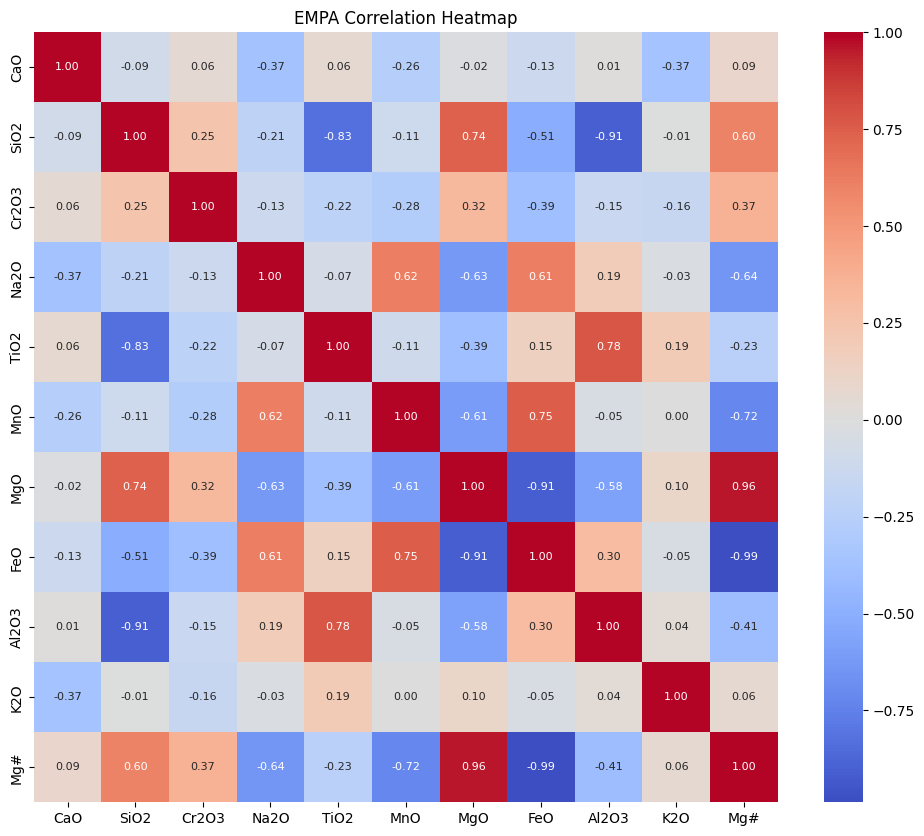

In [ ]:
# Generate the EMPA correlation heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
sns.heatmap(
    df_empa_scaled.corr(), # ← Calculate the correlation matrix
    cmap='coolwarm',
    center=0,          # ← Make 0 (no correlation) the middle color
    annot=True,        # ← Show correlation values
    fmt=".2f",         # ← Format numbers to 2 decimal places
    annot_kws={"size": 8}  # ← Smaller text)
)

plt.title("EMPA Correlation Heatmap")
plt.show()

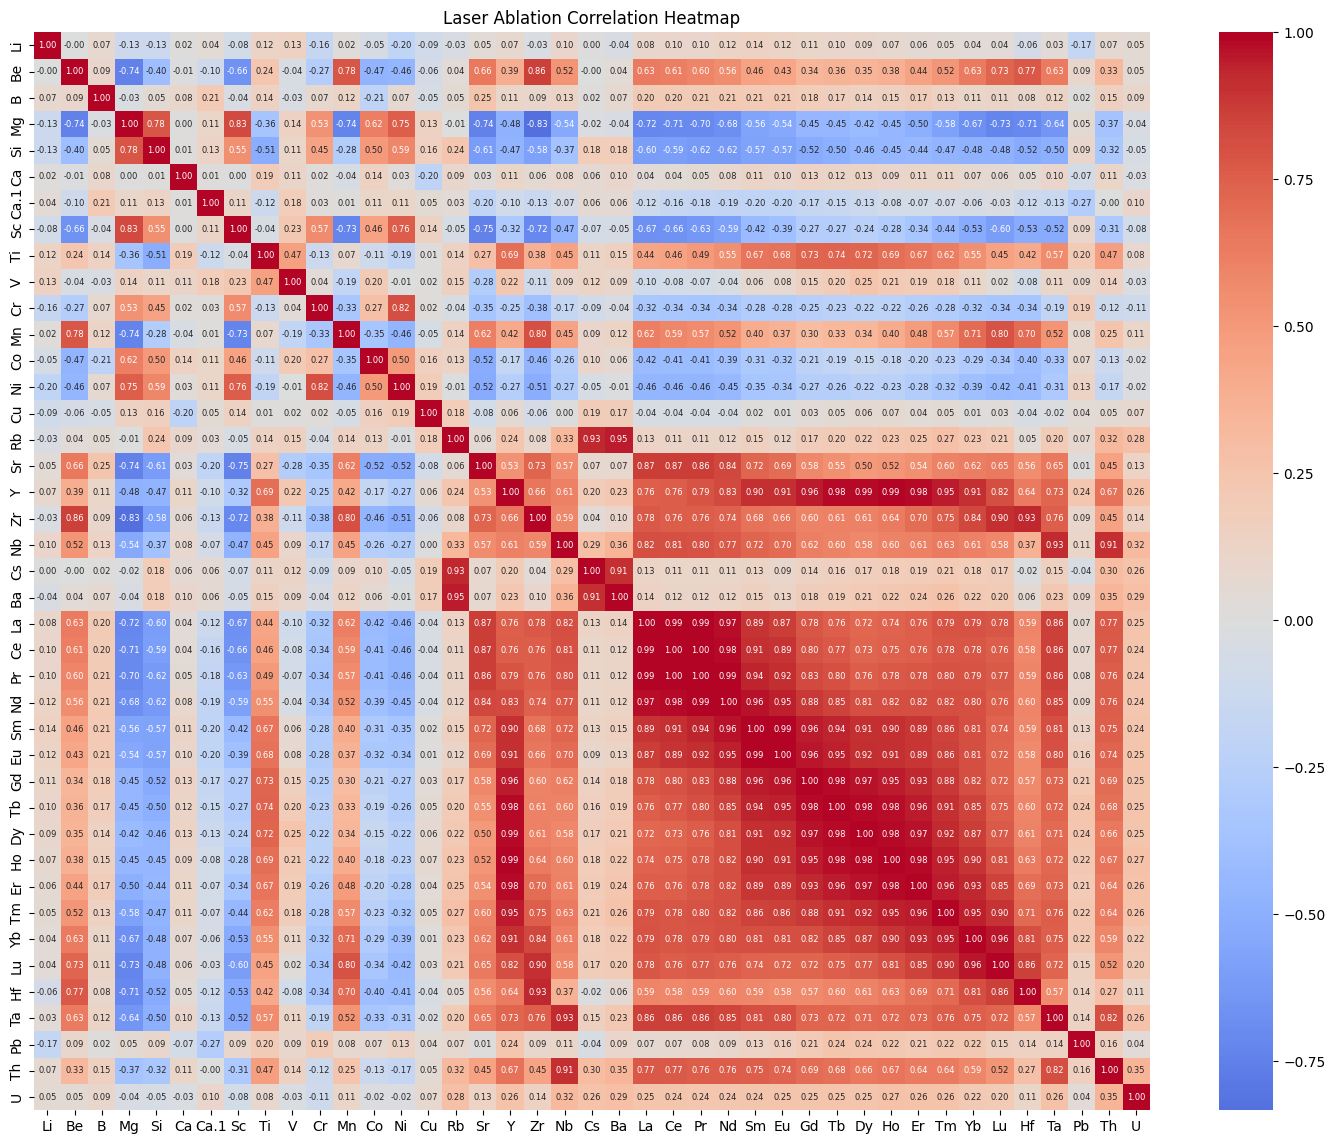

In [ ]:
# Generate the Laser correlation heatmap
# Laser has many more elements, so we make the figure bigger

plt.figure(figsize=(18, 14))
sns.heatmap(
    df_laser_scaled.corr(),
    cmap='coolwarm',
    center=0,
    annot=True,        # ← Show correlation values
    fmt=".2f",         # ← Format numbers (2 decimal places)
    annot_kws={"size": 6}  # ← Smaller text so it fits
    )
plt.title("Laser Ablation Correlation Heatmap")
plt.show()

## 3. Feature Selection

In [ ]:
# Create final EMPA feature sets
empa_selected = ['SiO2', 'MgO', 'FeO', 'CaO', 'Cr2O3', 'TiO2', 'Na2O', 'K2O']
X_empa_final = df_empa_scaled[empa_selected]

In [ ]:
# Create final Laser feature sets
laser_selected = ['Li','B','Mg','Si','Ca','Sc','Ti','V',
                  'Zr','La','Yb','Pb','Cs','Rb','Ba','Th','U']

X_laser_final = df_laser_scaled[laser_selected]

Feature selection was performed using correlation heatmaps.
Highly correlated variables (e.g., REEs, HFSEs, MgO–Mg#, SiO₂–Al₂O₃) were reduced to representative features to avoid redundancy and improve model performance.

This reduced the EMPA dataset from 11 to 8 features and the Laser dataset from 41 to ~15 features while preserving geochemical information.

In [ ]:
# Extract Labels
# Choose T out of C, M, R, T
# As T is the clearest classification

# Extract labels for EMPA
y_empa = df_empa['T']

In [ ]:
# Extract labels for Laser
y_laser = df_laser_clean['T']

In [ ]:
# Check the labels
y_empa.value_counts()
y_laser.value_counts()

,count
T,
1,78
3,59
2,52


The target variable (T) represents the mineral zone and is encoded numerically (1 = core, 2 = mantle, 3 = rim).
These labels were used as the classification targets for both EMPA and Laser datasets.

## 4. Machine Learning and Deep Learning

In [ ]:
# X_empa_final >>> selected + scaled EMPA features
# y_empa >>> zone labels (1 = core, 2 = mantle, 3 = rim)

In [ ]:
# Built EMPA model

# Train/test split
from sklearn.model_selection import train_test_split

X_train_empa, X_test_empa, y_train_empa, y_test_empa = train_test_split(
    X_empa_final, y_empa, test_size=0.2, random_state=42, stratify=y_empa
)

# test_size=0.2 → 80% training, 20% testing
# stratify=y_empa → keeps C/M/R balanced in both sets
# random_state=42 → reproducible results

In [ ]:
# Train the Logistic Regression model (EMPA)
from sklearn.linear_model import LogisticRegression

# Logistic Regression model (EMPA)
log_reg_empa = LogisticRegression(max_iter=500, multi_class='multinomial')
log_reg_empa.fit(X_train_empa, y_train_empa)

# multinomial handles 3 classes (1, 2, 3)
# max_iter=500 avoids convergence warnings

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=500, multi_class='multinomial')

In [ ]:
# Predictions
y_pred_empa = log_reg_empa.predict(X_test_empa)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Evaluation
print("Accuracy:", accuracy_score(y_test_empa, y_pred_empa))
print("\nClassification Report:\n", classification_report(y_test_empa, y_pred_empa))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_empa, y_pred_empa))

Accuracy: 0.6106870229007634

Classification Report:
               precision    recall  f1-score   support

           1       0.57      0.55      0.56        53
           2       0.66      0.85      0.74        52
           3       0.54      0.27      0.36        26

    accuracy                           0.61       131
   macro avg       0.59      0.55      0.55       131
weighted avg       0.60      0.61      0.59       131


Confusion Matrix:
 [[29 18  6]
 [ 8 44  0]
 [14  5  7]]


In [ ]:
# Built Laser model

# Train/test split
from sklearn.model_selection import train_test_split

X_train_laser, X_test_laser, y_train_laser, y_test_laser = train_test_split(
    X_laser_final, y_laser, test_size=0.2, random_state=42, stratify=y_laser
)

In [ ]:
# Train the Logistic Regression model (Laser)
from sklearn.linear_model import LogisticRegression

# Logistic Regression model (Laser)
log_reg_laser = LogisticRegression(max_iter=500, multi_class='multinomial')
log_reg_laser.fit(X_train_laser, y_train_laser)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=500, multi_class='multinomial')

In [ ]:
# Predictions
y_pred_laser = log_reg_laser.predict(X_test_laser)

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test_laser, y_pred_laser))
print("\nClassification Report:\n", classification_report(y_test_laser, y_pred_laser))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_laser, y_pred_laser))

Accuracy: 0.7368421052631579

Classification Report:
               precision    recall  f1-score   support

           1       0.67      0.75      0.71        16
           2       0.64      0.70      0.67        10
           3       1.00      0.75      0.86        12

    accuracy                           0.74        38
   macro avg       0.77      0.73      0.74        38
weighted avg       0.76      0.74      0.74        38


Confusion Matrix:
 [[12  4  0]
 [ 3  7  0]
 [ 3  0  9]]


In [ ]:
# Random Forest Classification
# --- it handles non‑linear boundaries
# --- it handles imbalanced classes better
# --- it captures element interactions

In [ ]:
# Built EMPA model

# Train/test split
from sklearn.model_selection import train_test_split

X_train_empa, X_test_empa, y_train_empa, y_test_empa = train_test_split(
    X_empa_final, y_empa, test_size=0.2, random_state=42, stratify=y_empa
)

In [ ]:
# Train the Random Forest model (EMPA)

from sklearn.ensemble import RandomForestClassifier

rf_empa = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    class_weight='balanced'
)

rf_empa.fit(X_train_empa, y_train_empa)

# n_estimators=300 → stable, strong model
# class_weight='balanced' → helps Rim (class 3)
# max_depth=None → lets the forest grow naturally

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

In [ ]:
# Predictions
y_pred_empa = rf_empa.predict(X_test_empa)

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test_empa, y_pred_empa))
print("\nClassification Report:\n", classification_report(y_test_empa, y_pred_empa))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_empa, y_pred_empa))

Accuracy: 0.6641221374045801

Classification Report:
               precision    recall  f1-score   support

           1       0.69      0.64      0.67        53
           2       0.65      0.81      0.72        52
           3       0.65      0.42      0.51        26

    accuracy                           0.66       131
   macro avg       0.66      0.62      0.63       131
weighted avg       0.67      0.66      0.66       131


Confusion Matrix:
 [[34 16  3]
 [ 7 42  3]
 [ 8  7 11]]


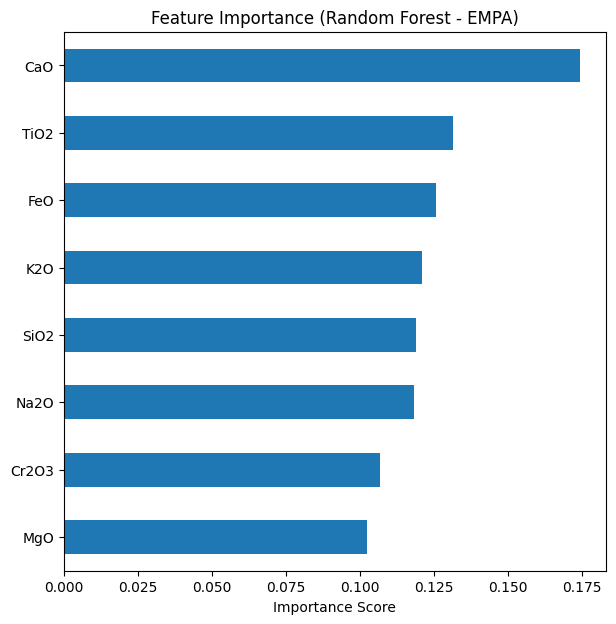

In [ ]:
#Feature Importance
importances_empa = pd.Series(rf_empa.feature_importances_, index=X_empa_final.columns)

importances_empa.sort_values().plot(kind='barh', figsize=(7,7))
plt.title("Feature Importance (Random Forest - EMPA)")
plt.xlabel("Importance Score")
plt.show()

In [ ]:
# Built Laser model

# Train/test split
from sklearn.model_selection import train_test_split

X_train_laser, X_test_laser, y_train_laser, y_test_laser = train_test_split(
    X_laser_final, y_laser, test_size=0.2, random_state=42, stratify=y_laser
)

In [ ]:
# Train the Random Forest model (Laser)
from sklearn.ensemble import RandomForestClassifier

rf_laser = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    random_state=42,
    class_weight='balanced'
)

rf_laser.fit(X_train_laser, y_train_laser)

# 400 trees → stable, strong model, larger data than EMPA
# class_weight='balanced' → helps Rim (class 3)
# max_depth=None → lets the forest learn complex boundaries

RandomForestClassifier(class_weight='balanced', n_estimators=400,
                       random_state=42)

In [ ]:
# Predictions
y_pred_laser = rf_laser.predict(X_test_laser)

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test_laser, y_pred_laser))
print("\nClassification Report:\n", classification_report(y_test_laser, y_pred_laser))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_laser, y_pred_laser))

Accuracy: 0.868421052631579

Classification Report:
               precision    recall  f1-score   support

           1       0.87      0.81      0.84        16
           2       0.73      0.80      0.76        10
           3       1.00      1.00      1.00        12

    accuracy                           0.87        38
   macro avg       0.86      0.87      0.87        38
weighted avg       0.87      0.87      0.87        38


Confusion Matrix:
 [[13  3  0]
 [ 2  8  0]
 [ 0  0 12]]


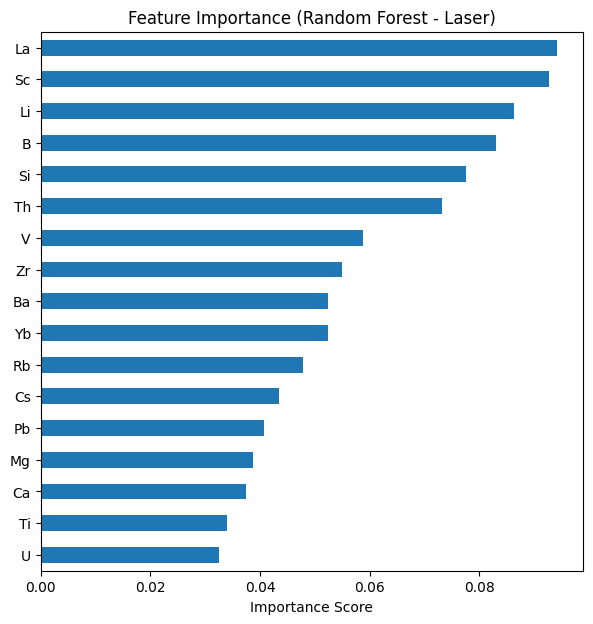

In [ ]:
#Feature Importance
importances_laser = pd.Series(rf_laser.feature_importances_, index=X_laser_final.columns)

importances_laser.sort_values().plot(kind='barh', figsize=(7,7))
plt.title("Feature Importance (Random Forest - Laser)")
plt.xlabel("Importance Score")
plt.show()

In [ ]:
# SVM Model For EMPA Data

# Import machine learning tools
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# Create an SVM classifier
# - kernel='rbf' allows non-linear decision boundaries
# - C controls regularization (higher = more complex model)
# - gamma='scale' is the recommended default for RBF
svm_empa = SVC(kernel='rbf', C=1, gamma='scale')

# Train the SVM model using the final EMPA feature set
svm_empa.fit(X_empa_final, y_empa)

# Predict labels for the training data
# (You can later replace this with test data if you split the dataset)
y_pred_empa_svm = svm_empa.predict(X_empa_final)

# Print evaluation metrics
print("=== EMPA SVM MODEL RESULTS ===")
print(confusion_matrix(y_empa, y_pred_empa_svm))  # Shows correct vs incorrect predictions
print(classification_report(y_empa, y_pred_empa_svm))  # Precision, recall, F1-score


=== EMPA SVM MODEL RESULTS ===
[[208  49   5]
 [ 23 235   4]
 [ 36  32  61]]
              precision    recall  f1-score   support

           1       0.78      0.79      0.79       262
           2       0.74      0.90      0.81       262
           3       0.87      0.47      0.61       129

    accuracy                           0.77       653
   macro avg       0.80      0.72      0.74       653
weighted avg       0.78      0.77      0.76       653



In [ ]:
# SVM Model For Laser Data

# Create an SVM classifier for Laser dataset
svm_laser = SVC(kernel='rbf', C=1, gamma='scale')

# Train the model using the final Laser feature set
svm_laser.fit(X_laser_final, y_laser)

# Predict labels for the Laser dataset
y_pred_laser_svm = svm_laser.predict(X_laser_final)

# Print evaluation metrics
print("=== LASER SVM MODEL RESULTS ===")
print(confusion_matrix(y_laser, y_pred_laser_svm))
print(classification_report(y_laser, y_pred_laser_svm))


=== LASER SVM MODEL RESULTS ===
[[66  9  3]
 [ 1 49  2]
 [ 3  0 56]]
              precision    recall  f1-score   support

           1       0.94      0.85      0.89        78
           2       0.84      0.94      0.89        52
           3       0.92      0.95      0.93        59

    accuracy                           0.90       189
   macro avg       0.90      0.91      0.91       189
weighted avg       0.91      0.90      0.90       189



In [ ]:
# Build the Deep Learning Model (Laser Dataset)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

# Sequential: build a neural network layer-by-layer, in a straight line
# Dense: a fully connected layer
#        (every neuron connects to every neuron in the next layer)
# Dropout: a layer that randomly turns off some neurons to prevent overfitting
# to_categorical: converts class labels like 1, 2, 3
#                 into a format the neural network understands (one-hot vectors)


# Convert labels to one-hot encoding
# Neural networks usually expect classes starting from 0
y_train_laser_cat = to_categorical(y_train_laser - 1)  # classes 0,1,2
y_test_laser_cat = to_categorical(y_test_laser - 1)

# Build the model
model_laser = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_laser.shape[1],)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(3, activation='softmax')  # 3 classes
])


# Dense(64) → first hidden layer with 64 neurons

# activation='relu' → helps the network learn non-linear patterns

# X_train_laser.shape[1] → number of features (columns) in Laser data
# This tells the model: “Each sample has this many input numbers”

# Dropout(0.2) →
# During training, randomly turns off 20% of neurons in the previous layer
# To prevent from overfitting

# Dense(32, activation='relu') →
# Second hidden layer with 32 neurons, again uses ReLU to learn patterns

# Dense(3, activation='softmax') →
# Output layer with 3 neurons: one for each class (core, mantle, rim)

# softmax turns the outputs into probabilities that sum to 1,
# e.g. [0.1, 0.2, 0.7]

model_laser.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# adam: popular algorithm that adjusts the model’s weights to reduce error

# categorical_crossentropy: loss function for multi-class classification with one-hot labels
# It measures how wrong the model’s predictions are

# accuracy: during training, the model will also report accuracy
#           so you can see how well it’s doing

# Train the model
history = model_laser.fit(
    X_train_laser, y_train_laser_cat,
    epochs=50,
    batch_size=8,
    validation_split=0.2,
    verbose=1
)

# history: Stores the training history (loss and accuracy per epoch) to plot it later

# One epoch = one full pass through the training data
# So 50 epochs = the model sees the whole training set 50 times

# batch_size: The model updates its weights after every X samples
# Smaller batch → more updates, more noise, sometimes better learning

# validation_split=0.2: 20% of the training data is held out as validation data
# The model doesn’t train on it, it only uses it to check if it’s overfitting

# verbose: Shows progress bar and metrics while training.


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.4167 - loss: 1.1222 - val_accuracy: 0.2903 - val_loss: 1.1381
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4583 - loss: 1.0195 - val_accuracy: 0.3871 - val_loss: 1.0252
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5000 - loss: 0.9364 - val_accuracy: 0.5161 - val_loss: 0.9397
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5750 - loss: 0.8978 - val_accuracy: 0.6452 - val_loss: 0.8830
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6417 - loss: 0.8448 - val_accuracy: 0.6452 - val_loss: 0.8440
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6500 - loss: 0.8229 - val_accuracy: 0.6774 - val_loss: 0.8101
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7250 - loss: 0.7475 - val_accuracy: 0.6774 - val_loss: 0.7693
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7167 - loss: 0.7041 - val_accuracy: 0.6774 - val_loss: 0.73

In [ ]:
# Predictions
y_pred_probs = model_laser.predict(X_test_laser)
y_pred_dl = y_pred_probs.argmax(axis=1) + 1  # convert back to classes 1,2,3

# model_laser.predict(X_test_laser)
# For each test sample, the model outputs probabilities for each class,
# e.g. [0.1, 0.2, 0.7] → most likely class 3

# argmax(axis=1): For each row, find the index of the largest value:
# [0.1, 0.2, 0.7] → index 2 (0-based)

# + 1: labels 1,2,3 originally, so you add 1 to go from [0,1,2] back to [1,2,3]

# Evaluation
print("Accuracy:", accuracy_score(y_test_laser, y_pred_dl))
print("\nClassification Report:\n", classification_report(y_test_laser, y_pred_dl))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_laser, y_pred_dl))


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Accuracy: 0.8947368421052632

Classification Report:
               precision    recall  f1-score   support

           1       1.00      0.81      0.90        16
           2       0.71      1.00      0.83        10
           3       1.00      0.92      0.96        12

    accuracy                           0.89        38
   macro avg       0.90      0.91      0.90        38
weighted avg       0.92      0.89      0.90        38


Confusion Matrix:
 [[13  3  0]
 [ 0 10  0]
 [ 0  1 11]]


## 5. Data Visualization

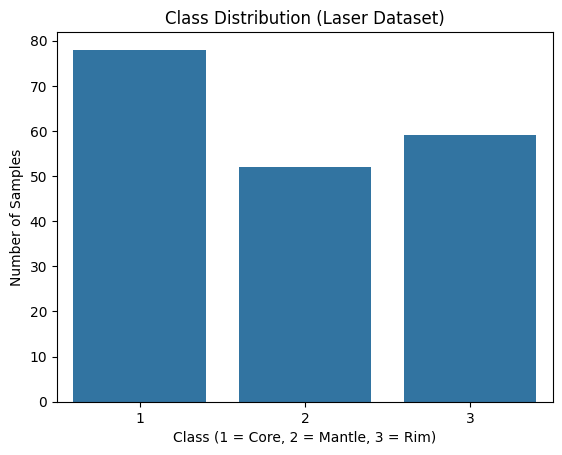

In [ ]:
# Class Distribution Plot
import seaborn as sns
import matplotlib.pyplot as plt

# y_laser contains labels (1, 2, 3)
# This plot shows how many samples are in each class
sns.countplot(x=y_laser)

# Add a title and axis labels
plt.title("Class Distribution (Laser Dataset)")
plt.xlabel("Class (1 = Core, 2 = Mantle, 3 = Rim)")
plt.ylabel("Number of Samples")

# Display the plot
plt.show()


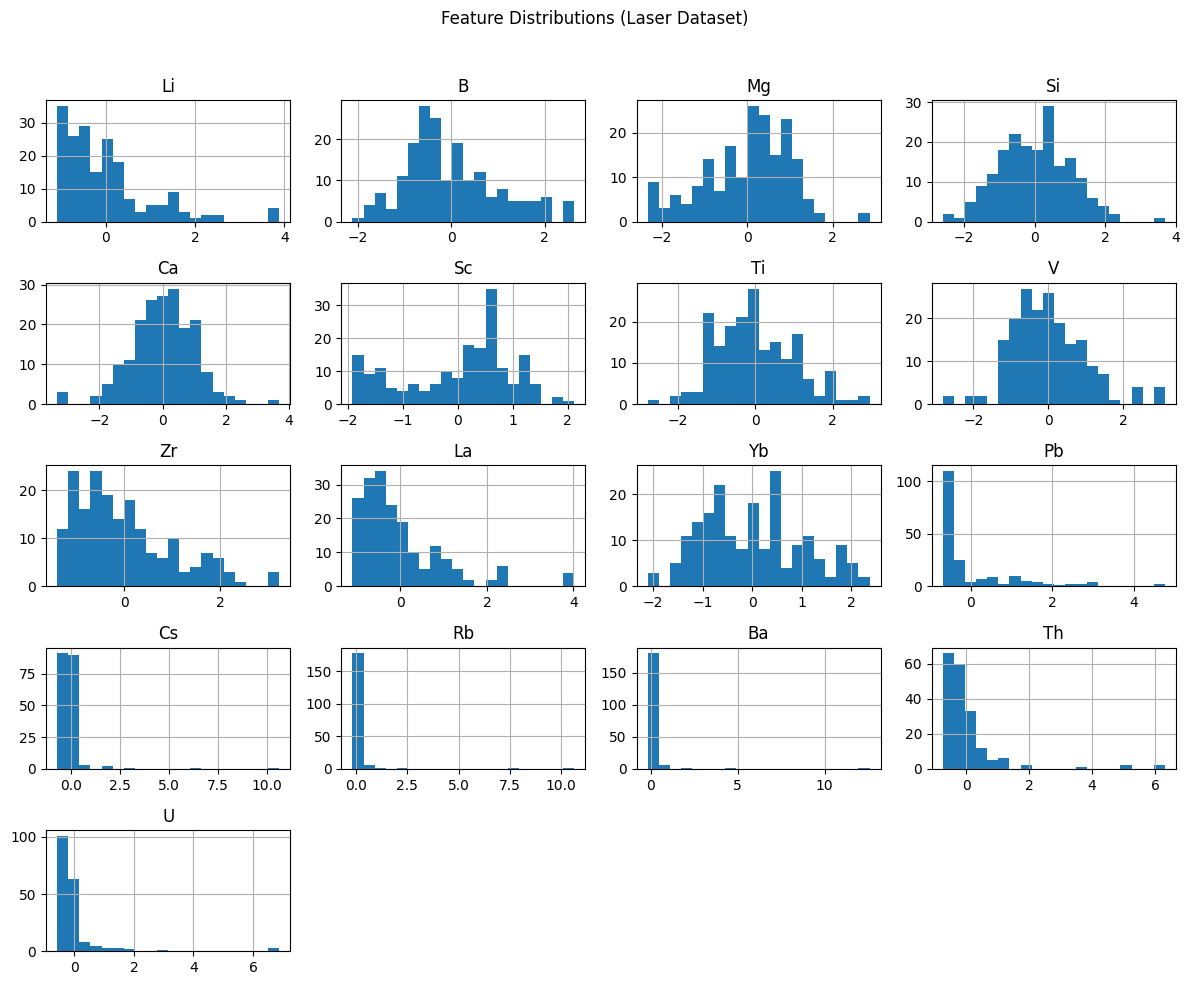

In [ ]:
# Histgram of Features

# X_laser_final is cleaned dataset with only the features
# .hist() automatically creates one histogram per column
X_laser_final.hist(figsize=(12, 10), bins=20)

# Add a title for the whole figure
plt.suptitle("Feature Distributions (Laser Dataset)")

# Adjust layout to prevent overlapping between title and subplots
# 'rect' moves the subplots down to make space for the suptitle
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Show the plot
plt.show()

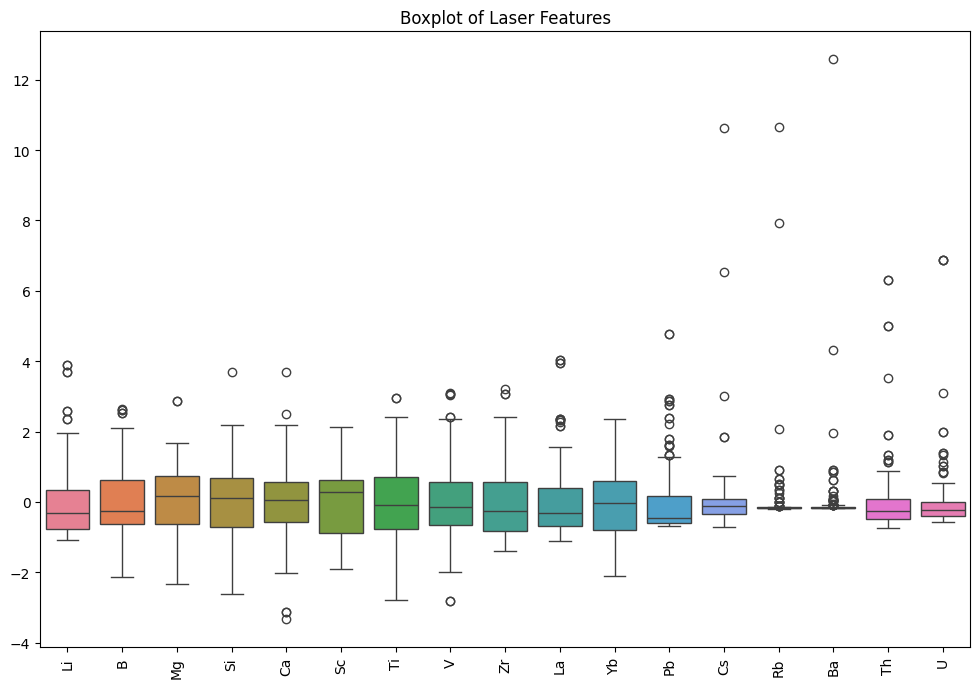

In [ ]:
# Boxplots for Outliers

plt.figure(figsize=(12, 8))

# sns.boxplot draws a boxplot for each column in the dataset
sns.boxplot(data=X_laser_final)

# Rotate labels so they don't overlap
plt.xticks(rotation=90)

plt.title("Boxplot of Laser Features")
plt.show()

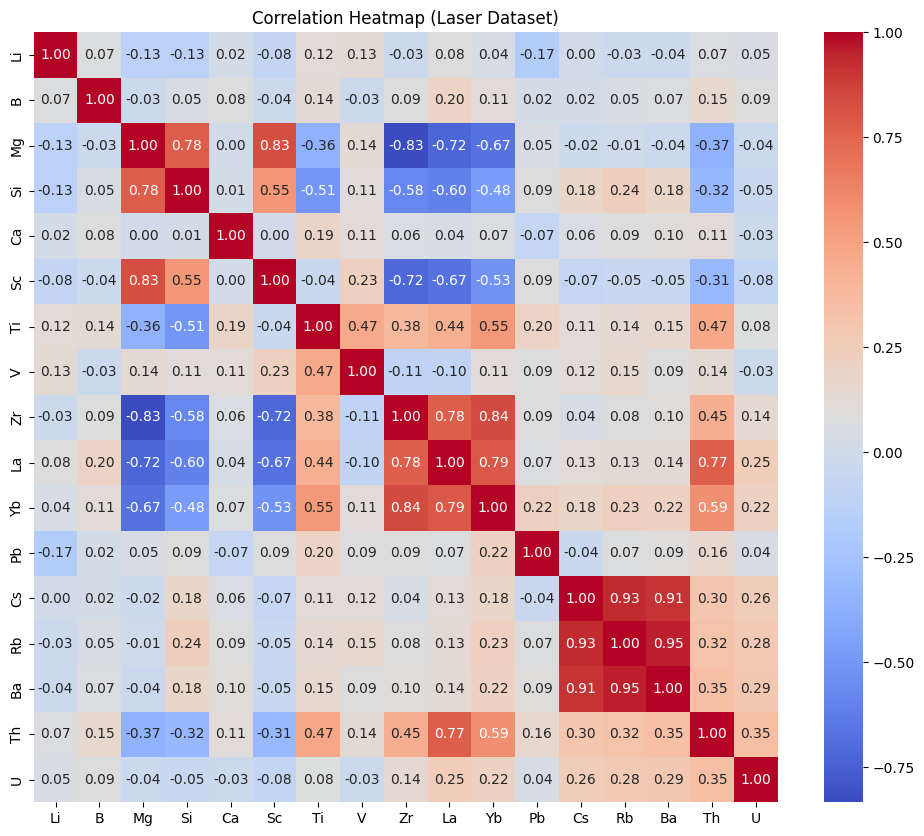

In [ ]:
# Correlation Heatmap

plt.figure(figsize=(12, 10))

# .corr() calculates correlation between every pair of features
# annot=False means we don't print numbers inside the boxes
sns.heatmap(X_laser_final.corr(),
            cmap="coolwarm",
            annot=True,
            fmt=".2f",
            )

plt.title("Correlation Heatmap (Laser Dataset)")
plt.show()

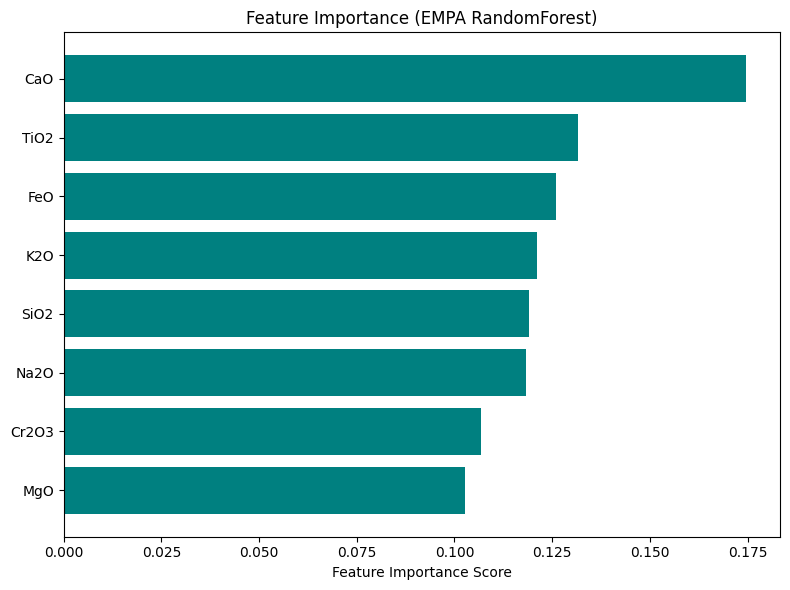

In [ ]:
# EMPA Feature Importance (Random forest)

import numpy as np
import matplotlib.pyplot as plt

def plot_feature_importance(model, feature_names, title):
    """
    Plots feature importance from a trained RandomForest model.
    """

    importances = model.feature_importances_
    indices = np.argsort(importances)

    plt.figure(figsize=(8, 6))
    plt.barh(range(len(importances)), importances[indices], color="teal")
    plt.yticks(range(len(importances)), np.array(feature_names)[indices])
    plt.xlabel("Feature Importance Score")
    plt.title(title)

    plt.tight_layout()
    plt.show()


# ===== EMPA RandomForest Feature Importance =====
plot_feature_importance(
    rf_empa,
    empa_selected,   # Picked 8 features
    "Feature Importance (EMPA RandomForest)"
)


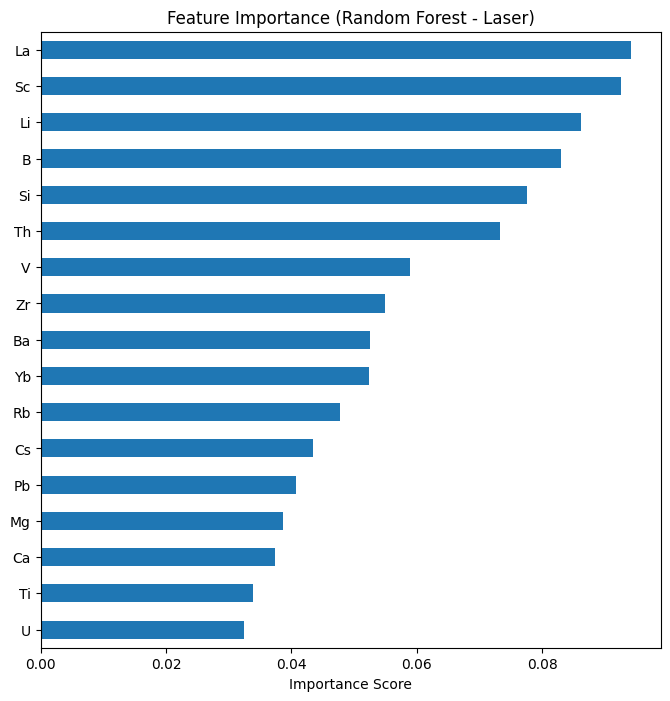

In [ ]:
# Laser Feature Importance (Random forest)

# rf_laser is trained Random Forest model
# .feature_importances_ gives importance scores for each feature
importances_laser = pd.Series(rf_laser.feature_importances_, index=X_laser_final.columns)

# Sort values so the smallest is at the bottom, largest at the top
importances_laser.sort_values().plot(kind='barh', figsize=(8, 8))

plt.title("Feature Importance (Random Forest - Laser)")
plt.xlabel("Importance Score")
plt.show()


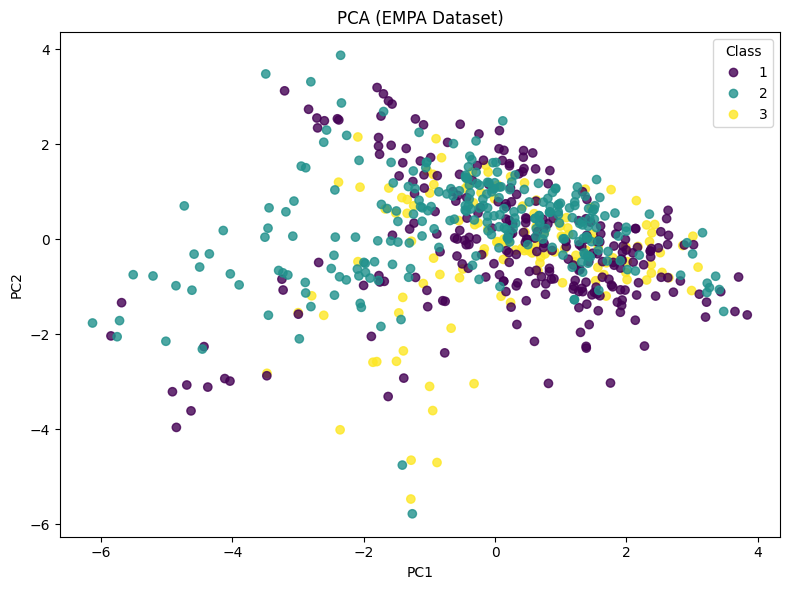

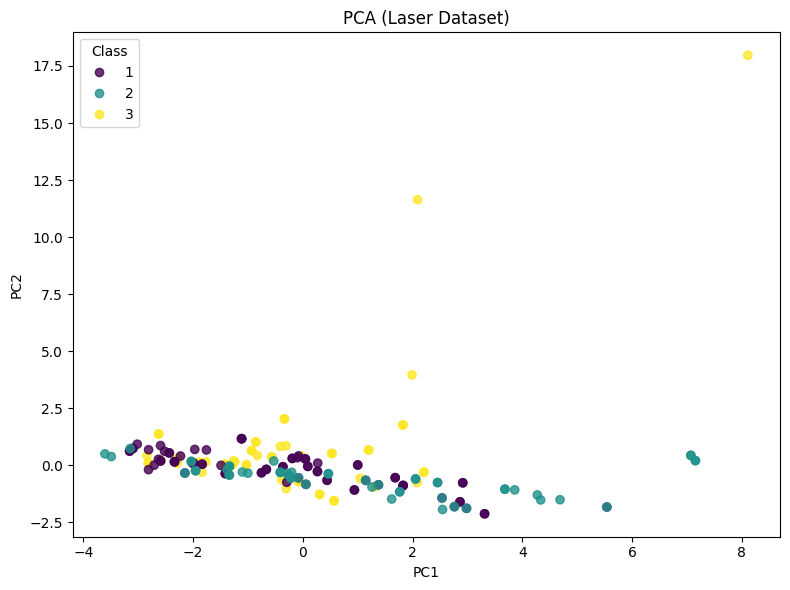

In [ ]:
# PCA Visualization Function (2D Scatter Plot)
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def plot_pca(X, y, title):
    """
    This function performs PCA (2 components) and visualizes the result.
    Each point is colored by its class label.
    """

    # Run PCA
    pca = PCA(n_components=2)　# HOw many comp
    X_pca = pca.fit_transform(X)

    # Create scatter plot
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(
        X_pca[:, 0], X_pca[:, 1],
        c=y, cmap="viridis", alpha=0.8
    )

    # Add labels and title
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(title)

    # Add legend for class labels
    plt.legend(*scatter.legend_elements(), title="Class")

    # Show plot
    plt.tight_layout()
    plt.show()


# ===== Run PCA for EMPA =====
plot_pca(X_empa_final, y_empa, "PCA (EMPA Dataset)")

# ===== Run PCA for Laser =====
plot_pca(X_laser_final, y_laser, "PCA (Laser Dataset)")

In [ ]:
# ============================================
# Universal Confusion Matrix Plot Function
# ============================================
# This function creates a clean, publication-quality confusion matrix
# for any classification model (LogReg, RF, SVM, Deep Learning, etc.)
# It ensures consistent formatting across all visualisations.

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_cm(y_true, y_pred, title, cmap="Blues"):
    """
    Draws a confusion matrix as a heatmap.
    Parameters:
        y_true : true labels
        y_pred : predicted labels
        title  : plot title
        cmap   : colormap (e.g., 'Blues', 'Greens', 'Oranges', 'Purples')
    """

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=cmap,
        xticklabels=["Core", "Mantle", "Rim"],
        yticklabels=["Core", "Mantle", "Rim"]
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.tight_layout()
    plt.show()

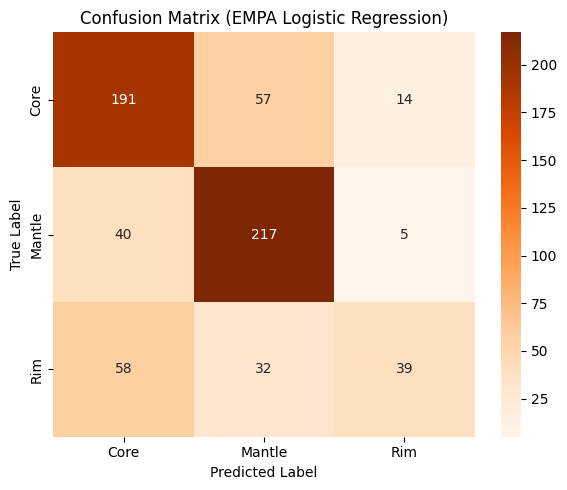

In [ ]:
# EMPA Logistic Regression Confusion Matrix
# Predict class labels using the trained Logistic Regression model
y_pred_empa_lr = log_reg_empa.predict(X_empa_final)

# Visualise the confusion matrix
plot_cm(y_empa, y_pred_empa_lr,  "Confusion Matrix (EMPA Logistic Regression)", cmap="Oranges")


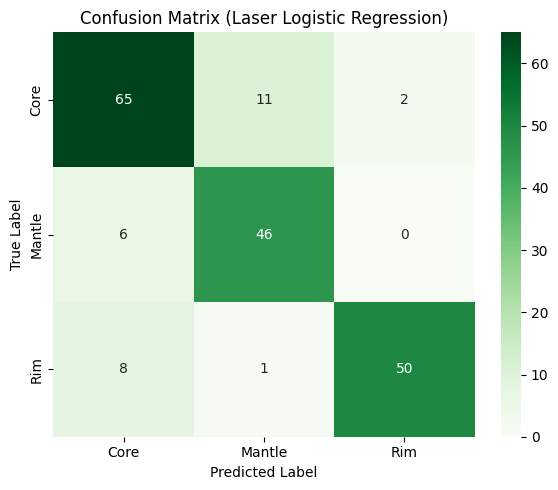

In [ ]:
# Laser Logistic Regression Confusion Matrix
# Predict class labels using the trained Logistic Regression model
y_pred_laser_lr = log_reg_laser.predict(X_laser_final)

# Visualise the confusion matrix
plot_cm(y_laser, y_pred_laser_lr,  "Confusion Matrix (Laser Logistic Regression)", cmap="Greens")

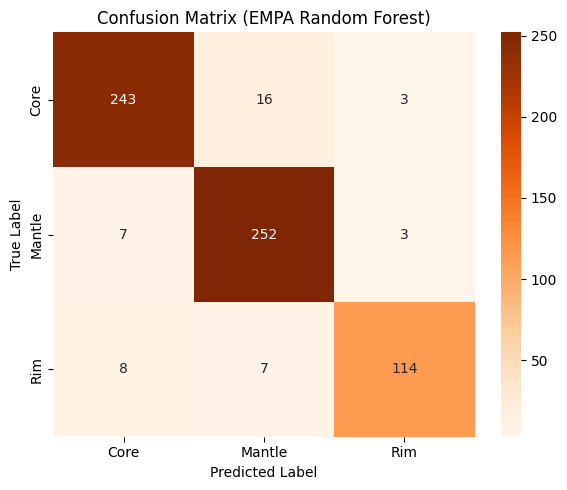

In [ ]:
# EMPA Random Forest Confusion Matrix
# Predict class labels using the trained Random Forest model
y_pred_empa_rf = rf_empa.predict(X_empa_final)

# Visualise the confusion matrix
plot_cm(y_empa, y_pred_empa_rf,  "Confusion Matrix (EMPA Random Forest)",      cmap="Oranges")

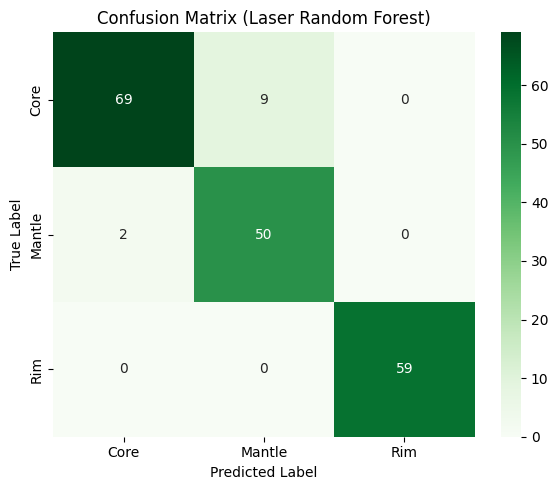

In [ ]:
# Laser Random Forest Confusion Matrix
# Predict class labels using the trained Random Forest model
y_pred_laser_rf = rf_laser.predict(X_laser_final)

# Visualise the confusion matrix
plot_cm(y_laser, y_pred_laser_rf,  "Confusion Matrix (Laser Random Forest)",      cmap="Greens")

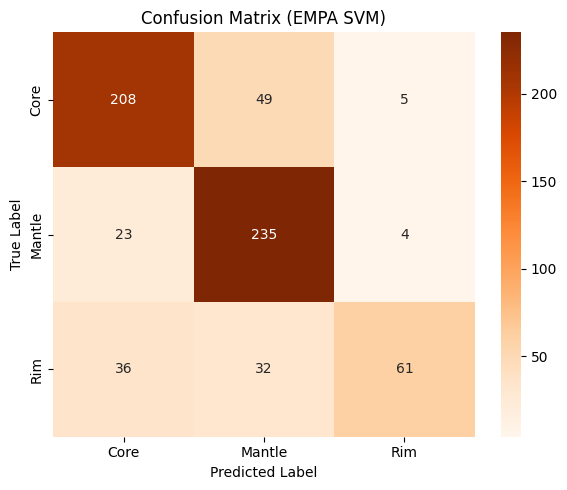

In [ ]:
# EMPA SVM Confusion Matrix
# Predict class labels using the trained SVM model
y_pred_empa_svm = svm_empa.predict(X_empa_final)

# Visualise the confusion matrix
plot_cm(y_empa, y_pred_empa_svm, "Confusion Matrix (EMPA SVM)",                cmap="Oranges")

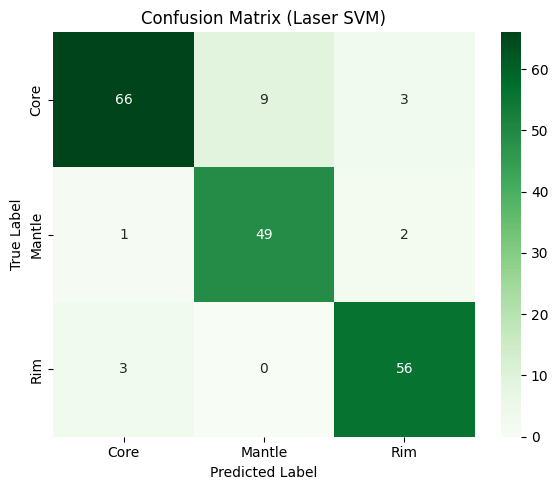

In [ ]:
# Laser SVM Confusion Matrix
# Predict class labels using the trained SVM model
y_pred_laser_svm = svm_laser.predict(X_laser_final)

# Visualise the confusion matrix
plot_cm(y_laser, y_pred_laser_svm, "Confusion Matrix (Laser SVM)",                cmap="Greens")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


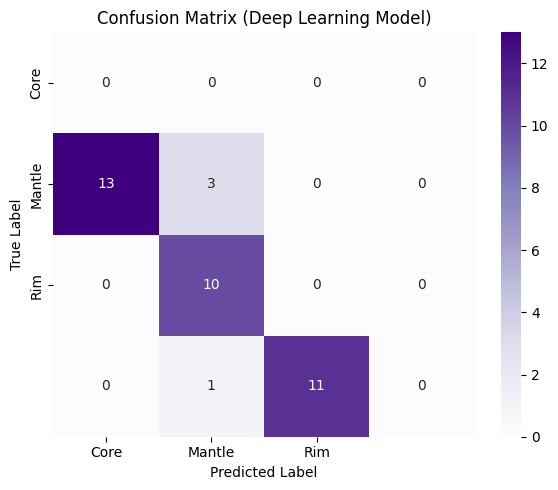

In [ ]:
# Deep Learning Confusion Matrix
# Predict class probabilities using the trained DL model
y_pred_dl = model_laser.predict(X_test_laser)

# Convert probability vectors to class labels
y_pred_dl_classes = np.argmax(y_pred_dl, axis=1)

# Visualise the confusion matrix
plot_cm(y_test_laser, y_pred_dl_classes, "Confusion Matrix (Deep Learning Model)", cmap="Purples")

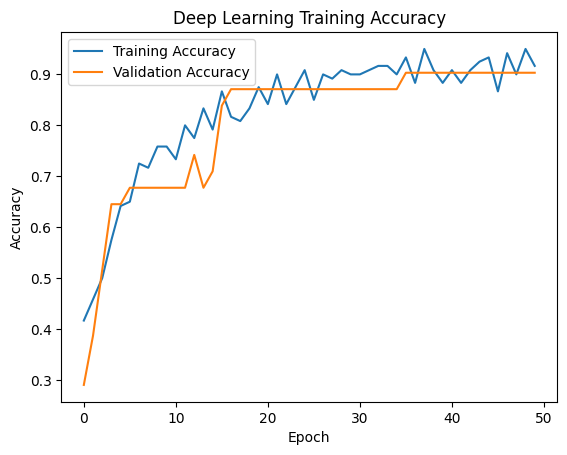

In [ ]:
# Deep Learning Training Curves

# history.history contains accuracy and loss for each epoch

# ---- Accuracy plot ----
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Deep Learning Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

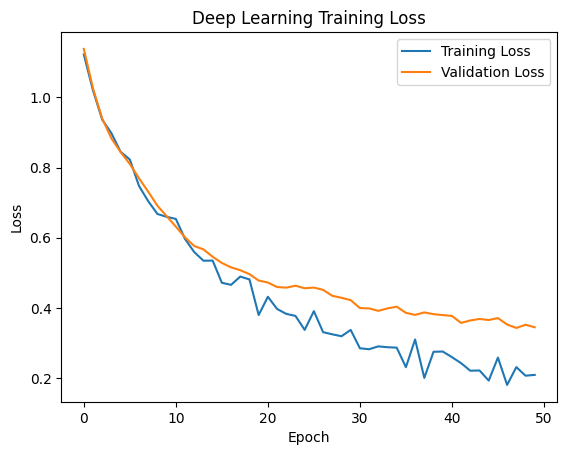

In [ ]:
# ---- Loss plot ----
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Deep Learning Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

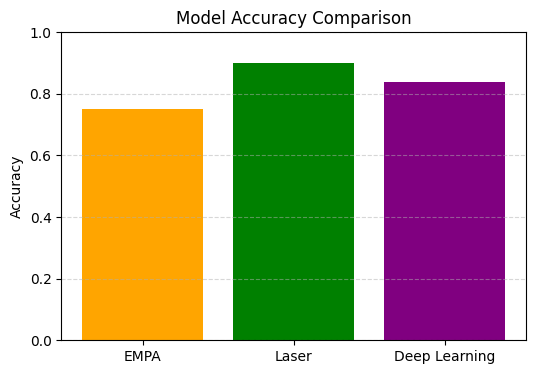

In [ ]:
import matplotlib.pyplot as plt

# Accuracy values
models = ["EMPA", "Laser", "Deep Learning"]
accuracy = [0.75, 0.90, 0.84]

plt.figure(figsize=(6, 4))
plt.bar(models, accuracy, color=["orange", "green", "purple"])
plt.ylim(0, 1)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()